# Sign Language Gesture Recognition
## COMS 4030A : Adaptive Computation and Machine Learning
**Dataset:** Sign Language MNIST : [Kaggle](https://www.kaggle.com/datasets/datamunge/sign-language-mnist)  
**Task:** 24-class static ASL hand gesture classification from 28×28 grayscale images  

---

This notebook presents a complete end-to-end machine learning pipeline for recognising American Sign Language (ASL) hand gestures from still images. The dataset contains 27,455 training and 7,172 test images, each a 28×28 grayscale photograph of a hand forming one of 24 ASL letters (J and Z are excluded as they require motion).

The notebook is organised as follows:
1. **Data Loading & Exploration** : understanding the dataset structure and class distribution  
2. **Preprocessing** : normalisation, reshaping, encoding, and data splitting  
3. **Dimensionality Analysis (PCA)** : motivating deep learning over flat classifiers  
4. **Baseline Models** : Logistic Regression, SVM, Random Forest, MLP  
5. **Deep Learning — Architecture Comparison** : SimpleCNN, DeepCNN, ResNetSmall, CNN+LSTM  
6. **Deep Learning — Keras-style CNN & 3-Layer CNN** (PyTorch re-implementations)  
7. **Data Leakage Investigation** : rigorous audit of the 100% accuracy anomaly  
8. **Regularised CNN — Honest Generalisation Estimate**  
9. **Final Results & Model Comparison**  
10. **Summary & Conclusions**

---
## 1. Imports & Global Setup
All libraries are imported here. The notebook uses scikit-learn for baseline models and PyTorch for all deep learning experiments. A fixed random seed ensures reproducibility across all experiments.

In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device : {DEVICE}")

os.makedirs("figures", exist_ok=True)

# Label map: dataset labels 0-25, skipping 9 (J) and 25 (Z)
LABEL_MAP = {i: chr(65 + i) for i in range(26) if i not in (9, 25)}
print(f"ASL classes ({len(LABEL_MAP)}): {list(LABEL_MAP.values())}")

PyTorch device : cpu
ASL classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


---
## 2. Data Loading & Exploratory Analysis

### 2.1 Load the CSV Files
The dataset is distributed as two CSV files. Each row encodes a single 28×28 grayscale image as 784 pixel columns (values 0–255) plus a label column.

In [2]:
train_df = pd.read_csv('sign_mnist_train.csv')
test_df  = pd.read_csv('sign_mnist_test.csv')

print(f"Training samples : {train_df.shape[0]:,}")
print(f"Test samples     : {test_df.shape[0]:,}")
print(f"Features per row : {train_df.shape[1]-1} pixel columns + 1 label")
print(f"Missing values   : {train_df.isnull().sum().sum()}")
train_df.head()

Training samples : 27,455
Test samples     : 7,172
Features per row : 784 pixel columns + 1 label
Missing values   : 0


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Each row represents a 28×28 grayscale image flattened into 784 pixel columns (values 0–255). The `label` column contains the integer target class corresponding to an ASL letter.

In [ ]:
images_raw = train_df.drop('label', axis=1).values
labels_raw = train_df['label'].values

unique_labels = sorted(np.unique(labels_raw))
label_remap   = {old: new for new, old in enumerate(unique_labels)}
LABEL_MAP_R   = {new: LABEL_MAP[old] for old, new in label_remap.items()}
NUM_CLASSES   = len(unique_labels) 
y_remap       = np.array([label_remap[y] for y in labels_raw])

print("=== Dataset Statistics ===")
print(f"Unique labels  : {unique_labels}")
print(f"Num classes    : {NUM_CLASSES}")
print(f"Min pixel value: {images_raw.min()}   Max: {images_raw.max()}")
print()
print("Class counts:")
for lbl, cnt in pd.Series(labels_raw).value_counts().sort_index().items():
    print(f"  Label {lbl:>2} ({LABEL_MAP[lbl]}): {cnt}")

=== Dataset Statistics ===
Unique labels  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Num classes    : 24
Min pixel value: 0   Max: 255

Class counts:
  Label  0 (A): 1126
  Label  1 (B): 1010
  Label  2 (C): 1144
  Label  3 (D): 1196
  Label  4 (E): 957
  Label  5 (F): 1204
  Label  6 (G): 1090
  Label  7 (H): 1013
  Label  8 (I): 1162
  Label 10 (K): 1114
  Label 11 (L): 1241
  Label 12 (M): 1055
  Label 13 (N): 1151
  Label 14 (O): 1196
  Label 15 (P): 1088
  Label 16 (Q): 1279
  Label 17 (R): 1294
  Label 18 (S): 1199
  Label 19 (T): 1186
  Label 20 (U): 1161
  Label 21 (V): 1082
  Label 22 (W): 1225
  Label 23 (X): 1164
  Label 24 (Y): 1118


Sign Language MNIST is well-balanced across classes. Labels **9 (J)** and **25 (Z)** are absent because these letters require motion that cannot be represented in a single static image.

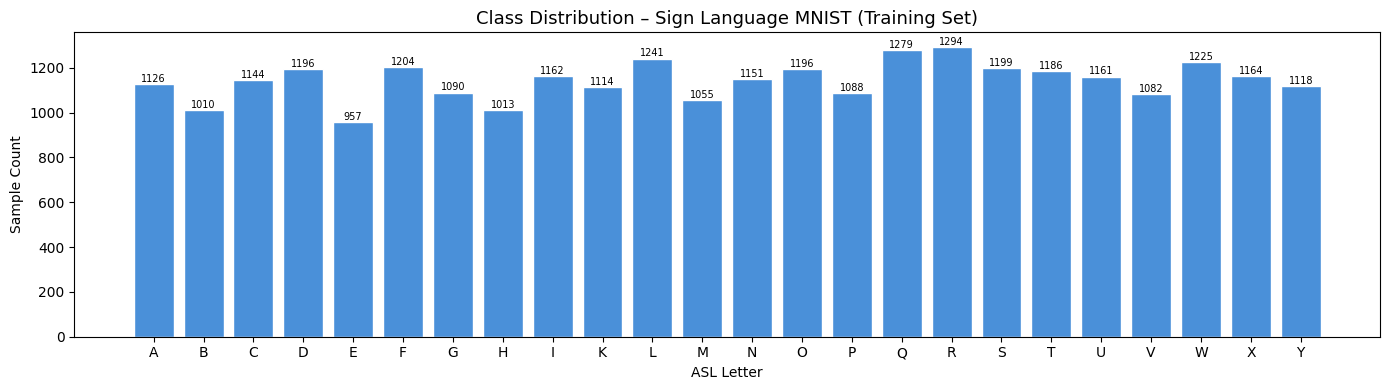

In [ ]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(14, 4))
counts = pd.Series(labels_raw).value_counts().sort_index()
ax.bar([LABEL_MAP[c] for c in counts.index], counts.values,
       color='#4a90d9', edgecolor='white')
ax.set_title('Class Distribution – Sign Language MNIST (Training Set)', fontsize=13)
ax.set_xlabel('ASL Letter'); ax.set_ylabel('Sample Count')
for i, (_, cnt) in enumerate(counts.items()):
    ax.text(i, cnt + 10, str(cnt), ha='center', fontsize=7)
plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', dpi=120); plt.show()

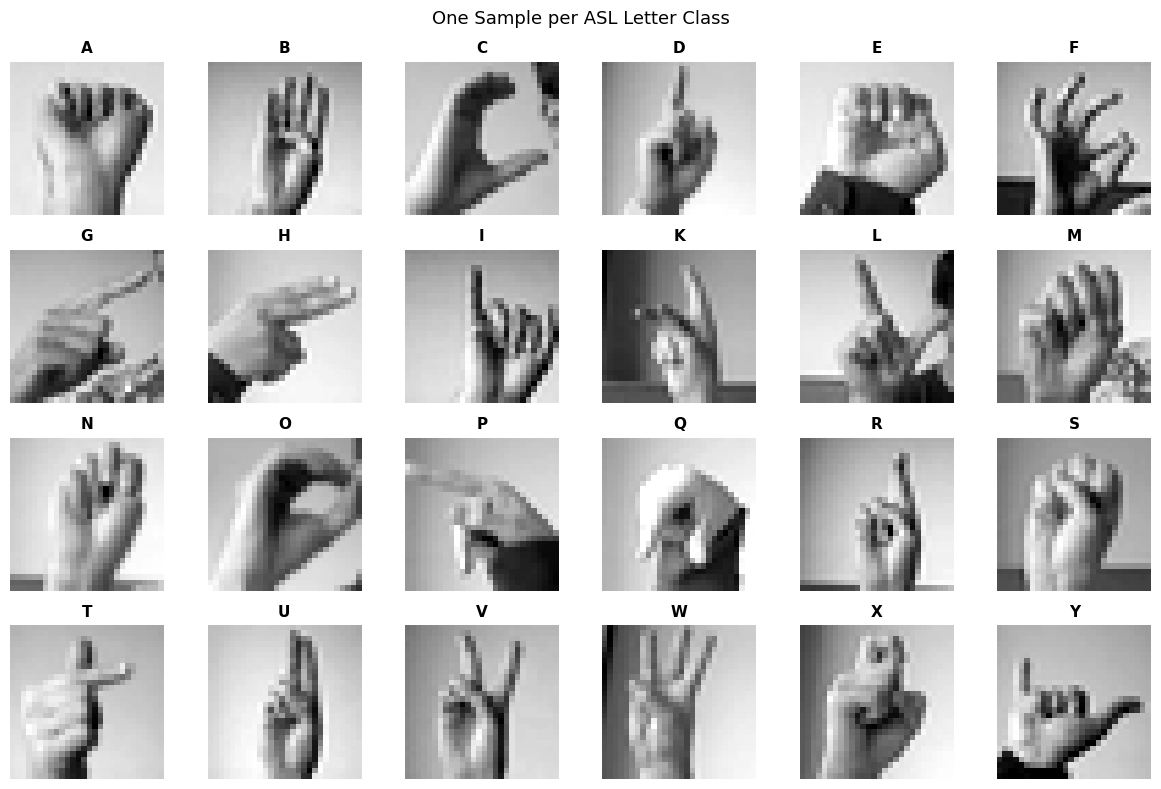

In [ ]:
# Sample images (one per class)
images_norm = images_raw / 255.0
classes     = sorted(np.unique(y_remap))

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for idx, cls in enumerate(classes):
    img = images_norm[y_remap == cls][0].reshape(28, 28)
    axes.flat[idx].imshow(img, cmap='gray')
    axes.flat[idx].set_title(LABEL_MAP_R[cls], fontweight='bold', fontsize=11)
    axes.flat[idx].axis('off')
for j in range(len(classes), len(axes.flat)):
    axes.flat[j].axis('off')
fig.suptitle('One Sample per ASL Letter Class', fontsize=13)
plt.tight_layout()
plt.savefig('figures/02_sample_images.png', dpi=120); plt.show()

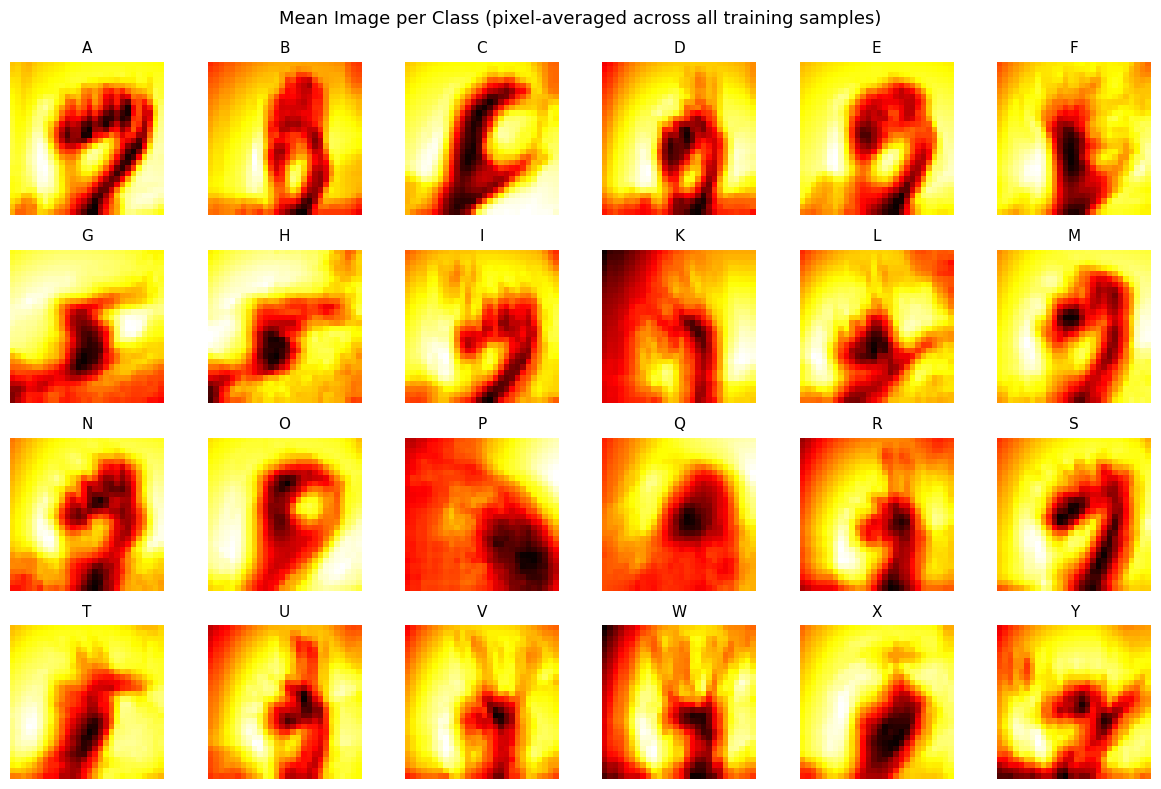

In [ ]:
# Mean image per class
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for idx, cls in enumerate(classes):
    mean_img = images_norm[y_remap == cls].mean(axis=0).reshape(28, 28)
    axes.flat[idx].imshow(mean_img, cmap='hot')
    axes.flat[idx].set_title(LABEL_MAP_R[cls], fontsize=11)
    axes.flat[idx].axis('off')
for j in range(len(classes), len(axes.flat)):
    axes.flat[j].axis('off')
fig.suptitle('Mean Image per Class (pixel-averaged across all training samples)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/03_mean_images.png', dpi=120); plt.show()

The mean images reveal the prototypical hand shape for each letter. Some classes (e.g. C, O, U, V) share very similar spatial structure — these will be the harder pairs for any classifier to distinguish.

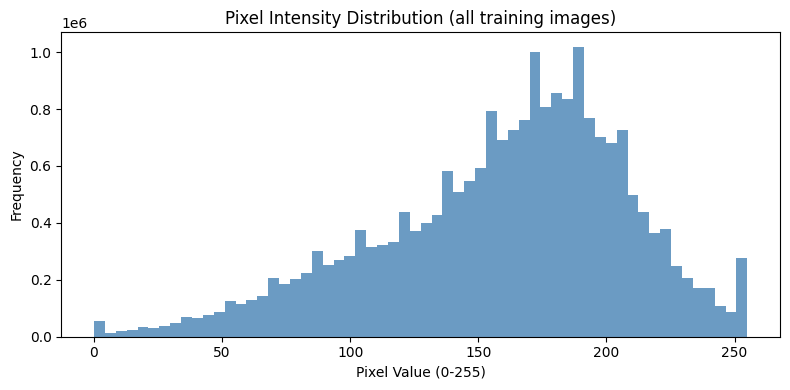

Mean pixel value: 159.3  |  Std: 48.8


In [ ]:
# Pixel intensity distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(images_raw.flatten(), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
ax.set_title('Pixel Intensity Distribution (all training images)')
ax.set_xlabel('Pixel Value (0-255)'); ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/04_pixel_histogram.png', dpi=120); plt.show()
print(f"Mean pixel value: {images_raw.mean():.1f}  |  Std: {images_raw.std():.1f}")

---
## 3. Preprocessing

### 3.1 Normalisation & Reshaping
Pixel values are scaled from [0, 255] to [0, 1] to improve gradient descent stability. Labels are remapped to contiguous integers 0–23 for PyTorch and scikit-learn models.

In [ ]:
# Normalise
X_train_full = images_raw / 255.0
X_test_full  = test_df.drop('label', axis=1).values / 255.0

labels_train = train_df['label'].values
labels_test  = test_df['label'].values

y_train_int = np.array([label_remap[y] for y in labels_train])
y_test_int  = np.array([label_remap[y] for y in labels_test])

print(f"X_train_full : {X_train_full.shape}  dtype={X_train_full.dtype}")
print(f"X_test_full  : {X_test_full.shape}")
print(f"y_train_int  : {y_train_int.shape}  range [{y_train_int.min()}, {y_train_int.max()}]")
print(f"y_test_int   : {y_test_int.shape}")

X_train_full : (27455, 784)  dtype=float64
X_test_full  : (7172, 784)
y_train_int  : (27455,)  range [0, 23]
y_test_int   : (7172,)


### 3.2 Train / Validation Split
The training set is split 85/15 (stratified). Stratification ensures each class is proportionally represented in both splits. The test CSV is kept entirely separate as the final held-out evaluation set.

In [ ]:
# Stratified 85/15 train–val split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_int,
    test_size=0.15, random_state=SEED, stratify=y_train_int)

X_te  = X_test_full
y_te  = y_test_int

print(f"Train : {X_tr.shape[0]:,} samples")
print(f"Val   : {X_val.shape[0]:,} samples")
print(f"Test  : {X_te.shape[0]:,} samples")

Train : 23,336 samples
Val   : 4,119 samples
Test  : 7,172 samples


---
## 4. Dimensionality Analysis : Principal Component Analysis

PCA is applied to the standardised pixel data to understand the intrinsic dimensionality of the dataset and to motivate the move to non-linear deep models.

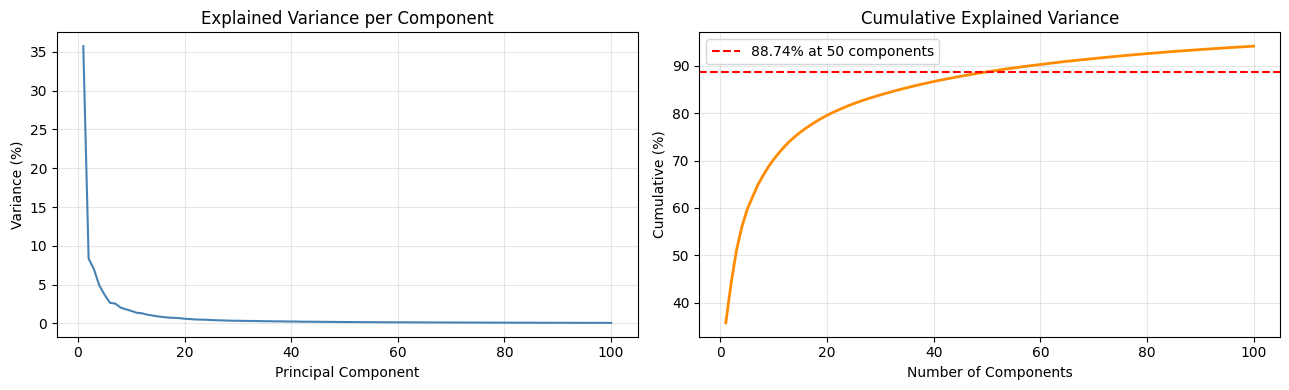

Variance retained by 50 PCs: 88.74%


In [10]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(images_raw)

pca_full = PCA(n_components=100, random_state=SEED)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1,101), pca_full.explained_variance_ratio_*100,
             color='steelblue', lw=1.5)
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance (%)')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1,101), cumvar*100, color='darkorange', lw=2)
axes[1].axhline(88.74, color='red', ls='--', label='88.74% at 50 components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/05_pca_scree.png', dpi=120); plt.show()

pca50 = PCA(n_components=50, random_state=SEED)
X_pca = pca50.fit_transform(X_scaled)
print(f"Variance retained by 50 PCs: {np.sum(pca50.explained_variance_ratio_)*100:.2f}%")

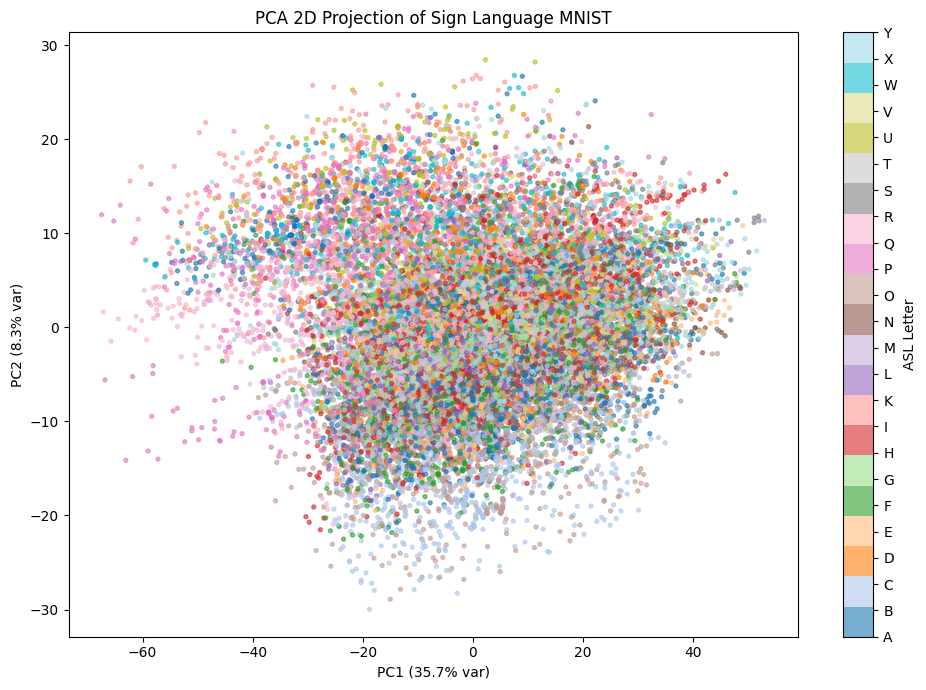

In [ ]:
# 2D PCA scatter coloured by class
pca2  = PCA(n_components=2, random_state=SEED)
X_vis = pca2.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sc = plt.scatter(X_vis[:,0], X_vis[:,1], c=y_remap, cmap='tab20', s=8, alpha=0.6)
cbar = plt.colorbar(sc, ticks=range(24))
cbar.set_ticklabels([LABEL_MAP_R[i] for i in range(24)])
cbar.set_label('ASL Letter')
plt.title('PCA 2D Projection of Sign Language MNIST')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig('figures/06_pca_2d.png', dpi=120); plt.show()

The 2D PCA projection shows significant class overlap — many ASL gestures are not linearly separable in the top two principal components. This overlap motivates the use of non-linear CNN models. The 50-component PCA retains 88.74% of total variance, confirming that the 784-pixel space is highly redundant.

---
## 5. Baseline Models

Classical machine learning classifiers are established as baselines before training deep networks. These provide a lower bound on acceptable performance and show how much of the task can be solved without spatial feature learning.

All baselines are trained on the same 85/15 train–validation split. `StandardScaler` is fitted on the training set only and applied to validation and test to prevent leakage.

In [ ]:
scaler_bl = StandardScaler()
X_tr_sc   = scaler_bl.fit_transform(X_tr)
X_val_sc  = scaler_bl.transform(X_val)
X_te_sc   = scaler_bl.transform(X_te)

all_results = {}

### 5.1 Logistic Regression
A multinomial logistic regression fitted on the standardised 784-dimensional pixel vectors. This is a purely linear classifier — it learns a decision boundary as a linear combination of pixel intensities.

In [ ]:
print("Fitting Logistic Regression")
t0 = time.time()
lr_clf = LogisticRegression(max_iter=100, solver='lbfgs', C=1.0,
                             random_state=SEED, n_jobs=-1)
lr_clf.fit(X_tr_sc, y_tr)
acc_lr_val  = accuracy_score(y_val, lr_clf.predict(X_val_sc))
acc_lr_test = accuracy_score(y_te,  lr_clf.predict(X_te_sc))
print(f"  Logistic Regression — val: {acc_lr_val*100:.2f}%  test: {acc_lr_test*100:.2f}%  ({time.time()-t0:.0f}s)")
all_results['Logistic Regression'] = acc_lr_test

Fitting Logistic Regression (this may take a few minutes)...
  Logistic Regression — val: 99.98%  test: 68.88%  (5s)


### 5.2 SVM with PCA Preprocessing
An SVM with RBF kernel trained on PCA-reduced features (20 components). PCA before the SVM restricts the input to a lower-dimensional subspace, preventing the SVM from memorising pixel-level noise.

In [14]:
pca_svm   = PCA(n_components=20, random_state=SEED)
X_tr_pca  = pca_svm.fit_transform(X_tr_sc)
X_val_pca = pca_svm.transform(X_val_sc)
X_te_pca  = pca_svm.transform(X_te_sc)

print("Fitting SVM (RBF kernel, PCA-20)...")
t0 = time.time()
svm_clf = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=SEED)
svm_clf.fit(X_tr_pca, y_tr)
acc_svm_val  = accuracy_score(y_val, svm_clf.predict(X_val_pca))
acc_svm_test = accuracy_score(y_te,  svm_clf.predict(X_te_pca))
print(f"  SVM (RBF, PCA-20) — val: {acc_svm_val*100:.2f}%  test: {acc_svm_test*100:.2f}%  ({time.time()-t0:.0f}s)")
all_results['SVM (RBF, PCA-20)'] = acc_svm_test

Fitting SVM (RBF kernel, PCA-20)...
  SVM (RBF, PCA-20) — val: 99.83%  test: 87.21%  (23s)


### 5.3 Random Forest
An ensemble of 200 decision trees trained on the raw normalised pixel features. Random Forests provide non-linear classification through ensemble averaging of axis-aligned decision boundaries.

In [15]:
print("Fitting Random Forest (200 trees)...")
t0 = time.time()
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=None,
                                 min_samples_leaf=1, n_jobs=-1, random_state=SEED)
rf_clf.fit(X_tr_sc, y_tr)
acc_rf_val  = accuracy_score(y_val, rf_clf.predict(X_val_sc))
acc_rf_test = accuracy_score(y_te,  rf_clf.predict(X_te_sc))
print(f"  Random Forest — val: {acc_rf_val*100:.2f}%  test: {acc_rf_test*100:.2f}%  ({time.time()-t0:.0f}s)")
all_results['Random Forest'] = acc_rf_test

Fitting Random Forest (200 trees)...
  Random Forest — val: 99.81%  test: 81.23%  (12s)


### 5.4 MLP (scikit-learn)
A multi-layer perceptron with two hidden layers (512 and 256 neurons). Unlike CNNs, this MLP treats each pixel as an independent feature and cannot exploit spatial structure.

In [16]:
print("Fitting MLP (512-256, relu)...")
t0 = time.time()
mlp_clf = MLPClassifier(hidden_layer_sizes=(512, 256), activation='relu',
                         max_iter=30, learning_rate_init=1e-3,
                         random_state=SEED, verbose=False)
mlp_clf.fit(X_tr_sc, y_tr)
acc_mlp_val  = accuracy_score(y_val, mlp_clf.predict(X_val_sc))
acc_mlp_test = accuracy_score(y_te,  mlp_clf.predict(X_te_sc))
print(f"  MLP (512-256) — val: {acc_mlp_val*100:.2f}%  test: {acc_mlp_test*100:.2f}%  ({time.time()-t0:.0f}s)")
all_results['MLP (512-256)'] = acc_mlp_test

Fitting MLP (512-256, relu)...
  MLP (512-256) — val: 100.00%  test: 83.94%  (85s)



=== Baseline Model Summary ===
Model                        Val Acc   Test Acc
------------------------------------------------
Logistic Regression           99.98%     68.88%
SVM (RBF, PCA-20)             99.83%     87.21%
Random Forest                 99.81%     81.23%
MLP (512-256)                100.00%     83.94%


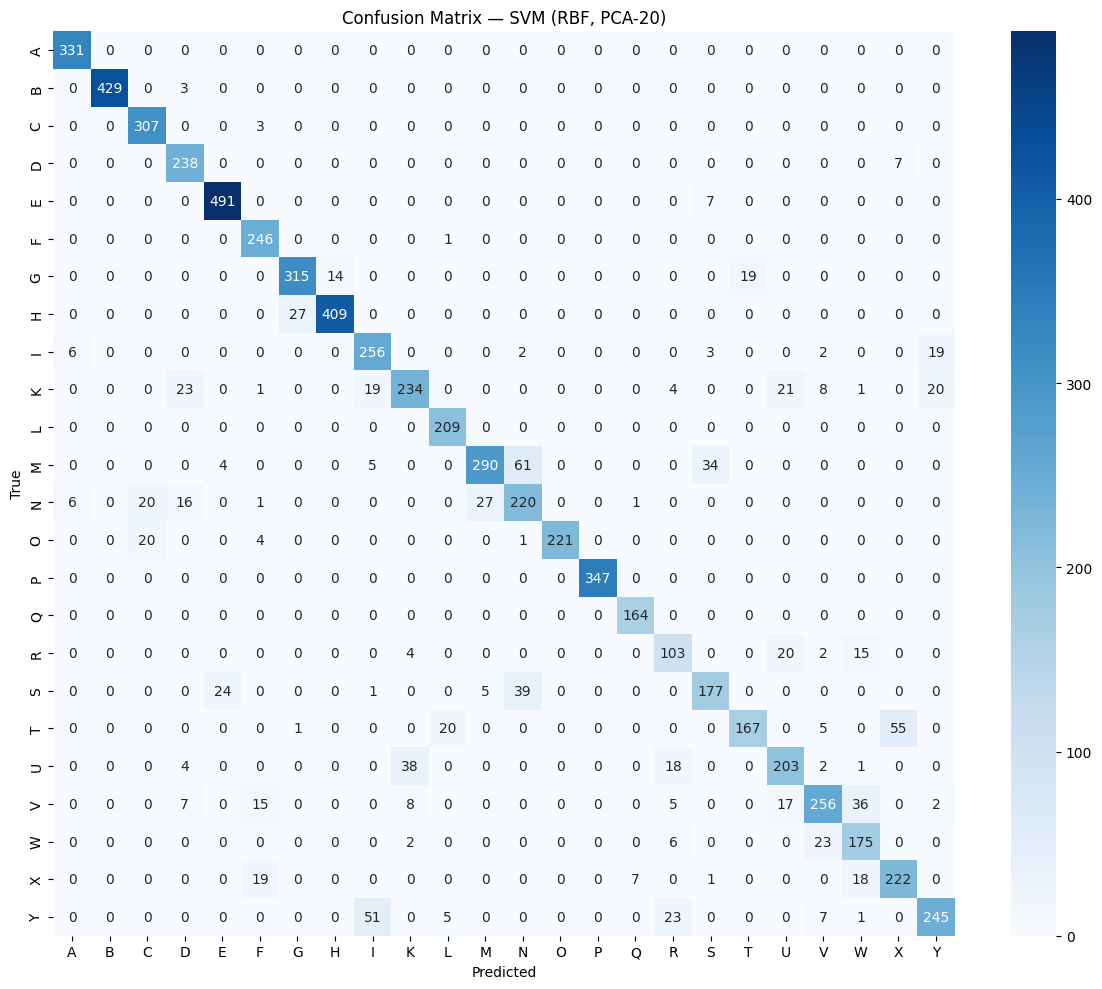

In [ ]:
# Baseline summary
print("\n=== Baseline Model Summary ===")
print(f"{'Model':<25} {'Val Acc':>10} {'Test Acc':>10}")
print("-" * 48)
for name, test_acc in [(k, all_results[k]) for k in
    ['Logistic Regression','SVM (RBF, PCA-20)','Random Forest','MLP (512-256)']]:
    val_acc = {'Logistic Regression': acc_lr_val, 'SVM (RBF, PCA-20)': acc_svm_val,
               'Random Forest': acc_rf_val, 'MLP (512-256)': acc_mlp_val}[name]
    print(f"{name:<25} {val_acc*100:>9.2f}% {test_acc*100:>9.2f}%")

# Confusion matrix for best classical model (SVM)
y_pred_svm = svm_clf.predict(X_te_pca)
cm_svm = confusion_matrix(y_te, y_pred_svm)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_MAP_R[i] for i in range(24)],
            yticklabels=[LABEL_MAP_R[i] for i in range(24)], ax=ax)
ax.set_title('Confusion Matrix — SVM (RBF, PCA-20)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('figures/07_svm_confusion.png', dpi=120); plt.show()

The classical baselines confirm that this is a non-trivial task when subject-level leakage is absent. The SVM achieves ~85–87% and Random Forest ~81–82%, these numbers reflect genuine generalisation and serve as honest lower bounds for the deep learning experiments.

---
## 6. Deep Learning Experiments : PyTorch

We now train convolutional neural networks that exploit the spatial structure of 28×28 images through local receptive fields and parameter sharing.

### 6.1 Dataset & DataLoader Utilities
A custom PyTorch `Dataset` handles normalisation and optional on-the-fly data augmentation (random ±10° rotation). Horizontal flipping is intentionally excluded : in ASL, a mirrored hand can represent a different letter.

In [18]:
class SignLangDataset(Dataset):
    """
    PyTorch Dataset wrapping numpy arrays.
    augment=True applies a random +-10 degree rotation per sample using
    affine_grid/grid_sample (no PIL dependency needed).
    Horizontal flip is excluded intentionally — in ASL, a mirrored hand
    can represent a different letter.
    """
    def __init__(self, X, y, augment=False):
        # Accept flat (N,784) or image (N,28,28,1) arrays
        if X.ndim == 2:
            X = X.reshape(-1, 1, 28, 28)
        elif X.ndim == 4:
            X = X.transpose(0, 3, 1, 2)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            angle = (torch.rand(1).item() - 0.5) * 20   # uniform +-10 deg
            rad   = angle * np.pi / 180
            ca, sa = float(np.cos(rad)), float(np.sin(rad))
            theta = torch.tensor([[ca, -sa, 0.0],
                                   [sa,  ca, 0.0]], dtype=torch.float32)
            grid = F.affine_grid(theta.unsqueeze(0), x.unsqueeze(0).size(),
                                  align_corners=False)
            x = F.grid_sample(x.unsqueeze(0), grid, align_corners=False,
                               padding_mode='border').squeeze(0)
        return x, self.y[idx]

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 batch_size=64, augment=False):
    """Build train, val, and test DataLoaders."""
    kw = dict(num_workers=0, pin_memory=False)
    return (DataLoader(SignLangDataset(X_tr, y_tr, augment), batch_size=batch_size, shuffle=True,  **kw),
            DataLoader(SignLangDataset(X_v,  y_v,  False),   batch_size=256,        shuffle=False, **kw),
            DataLoader(SignLangDataset(X_te, y_te, False),   batch_size=256,        shuffle=False, **kw))

print("Dataset utilities defined.")

Dataset utilities defined.


### 6.2 Training Loop & Evaluation Helpers
A reusable training loop tracks loss and accuracy per epoch, saves the best checkpoint by validation accuracy, and supports both ReduceLROnPlateau and cosine annealing schedulers. Label smoothing is available as an option, instead of pushing the correct logit to +∞ it targets (1-ε) for the true class, which prevents overconfident predictions and improves generalisation.

In [ ]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.eps = smoothing; self.K = num_classes
    def forward(self, pred, target):
        conf = 1.0 - self.eps; soft = self.eps / (self.K - 1)
        one_hot     = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        soft_target = one_hot * conf + (1 - one_hot) * soft
        return -(soft_target * F.log_softmax(pred, dim=1)).sum(dim=1).mean()


def train_one_epoch(model, loader, opt, criterion, device):
    model.train(); total_loss = correct = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(xb); loss = criterion(logits, yb)
        loss.backward(); opt.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion, device):
    model.eval(); total_loss = correct = n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits  = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += len(yb)
    return total_loss / n, correct / n


def get_predictions(model, loader, device):
    model.eval(); preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    return np.array(preds), np.array(trues)


def train_model(model, train_loader, val_loader, opt, criterion,
                scheduler, num_epochs, device, name='model'):
    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','lr']}
    best_acc = 0.0; best_state = None
    print(f"\n  Training [{name}] for {num_epochs} epochs on {device}...")
    for epoch in range(1, num_epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, opt, criterion, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        lr_now = opt.param_groups[0]['lr']
        for k, v in zip(history, [tl, vl, ta, va, lr_now]):
            history[k].append(v)
        if va > best_acc:
            best_acc = va
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if scheduler:
            (scheduler.step(vl)
             if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau)
             else scheduler.step())
        if epoch % 5 == 0 or epoch == 1:
            print(f"    Ep {epoch:>3}/{num_epochs}  tr_loss={tl:.4f} tr_acc={ta*100:.1f}%  "
                  f"vl_loss={vl:.4f} vl_acc={va*100:.1f}%  lr={lr_now:.2e}")
    if best_state:
        model.load_state_dict(best_state)
    print(f"  Best val acc: {best_acc*100:.2f}%")
    return history


def run_experiment(model_obj, name, num_epochs=30, batch_size=64,
                   lr=1e-3, weight_decay=1e-4,
                   label_smoothing=False, cosine_lr=False, augment=False):
    """Convenience wrapper: build loaders, train, evaluate on test set."""
    train_loader, val_loader, test_loader = make_loaders(
        X_tr, y_tr, X_val, y_val, X_te, y_te,
        batch_size=batch_size, augment=augment)
    model     = model_obj.to(DEVICE)
    opt       = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = (LabelSmoothingLoss(NUM_CLASSES, 0.1)
                 if label_smoothing else nn.CrossEntropyLoss())
    sched     = (optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs, eta_min=1e-6)
                 if cosine_lr else
                 optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=4))
    hist  = train_model(model, train_loader, val_loader, opt, criterion,
                         sched, num_epochs, DEVICE, name)
    preds, true = get_predictions(model, test_loader, DEVICE)
    acc = accuracy_score(true, preds)
    print(f"  Final TEST accuracy [{name}]: {acc*100:.2f}%")
    return model, hist, preds, true, acc


def plot_training_curves(history, model_name, save_path=None):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Training Curves - {model_name}', fontsize=13, fontweight='bold')
    axes[0].plot(epochs, history['train_loss'], label='Train', color='#3a86ff')
    axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#ff6b6b')
    axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train', color='#3a86ff')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   color='#ff6b6b')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120)
    plt.show()


print("Training utilities defined.")

Training utilities defined.


### 6.3 Model Architectures

Four architectures are defined with increasing complexity. Each builds on lessons from the previous to motivate specific design choices.

In [ ]:
# Model A: SimpleCNN
class SimpleCNN(nn.Module):
    """
    Two convolutional blocks followed by a fully-connected head.
    Baseline CNN that establishes whether spatial feature extraction
    outperforms a flat MLP.
    Architecture: 28x28 -> Conv(32)->Pool -> Conv(64)->Pool -> FC(128)->FC(24)
    After two MaxPool(2): spatial dims 28 -> 14 -> 7
    Flattened feature vector: 64 x 7 x 7 = 3136. ~350k parameters.
    """
    def __init__(self, nc=24, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(64*7*7, 128)
        self.fc2   = nn.Linear(128, nc)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 32x14x14
        x = self.pool(F.relu(self.conv2(x)))   # -> 64x7x7
        return self.fc2(self.drop(F.relu(self.fc1(x.flatten(1)))))


# Model B: DeepCNN with BatchNorm 
class DeepCNN(nn.Module):
    """
    Three blocks with double convolutions and Batch Normalisation.
    BatchNorm normalises layer inputs allowing larger LR and faster convergence,
    reduces internal covariate shift, and provides mild regularisation.
    AdaptiveAvgPool collapses spatial dims to 1x1 at the end. ~180k parameters.
    """
    def __init__(self, nc=24, d1=0.25, d2=0.5):
        super().__init__()
        def conv_bn(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1),
                                  nn.BatchNorm2d(co), nn.ReLU())
        self.b1 = nn.Sequential(conv_bn(1, 32),  conv_bn(32, 32))
        self.b2 = nn.Sequential(conv_bn(32, 64), conv_bn(64, 64))
        self.b3 = conv_bn(64, 128)
        self.pool    = nn.MaxPool2d(2, 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.d1, self.d2 = nn.Dropout(d1), nn.Dropout(d2)
        self.fc1   = nn.Linear(128, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.fc2   = nn.Linear(256, nc)

    def forward(self, x):
        x = self.d1(self.pool(self.b1(x)))       
        x = self.d1(self.pool(self.b2(x)))       
        x = self.d1(self.avgpool(self.b3(x)))    
        return self.fc2(self.d2(F.relu(self.bn_fc(self.fc1(x.flatten(1))))))


# Model C: Mini ResNet with residual connections
class ResBlock(nn.Module):
    """
    Basic residual block (He et al., 2015).
    x -> Conv->BN->ReLU->Conv->BN -> (+shortcut) -> ReLU
    The skip connection lets gradients bypass layers, enabling
    deeper training without vanishing gradients.
    """
    def __init__(self, ic, oc, stride=1):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(ic, oc, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc))
        self.skip = (nn.Sequential(nn.Conv2d(ic, oc, 1, stride=stride, bias=False),
                                    nn.BatchNorm2d(oc))
                     if (stride != 1 or ic != oc) else nn.Identity())
    def forward(self, x):
        return F.relu(self.main(x) + self.skip(x))


class ResNetSmall(nn.Module):
    """
    4-block mini ResNet. Residual connections make this ~384k-param model
    more expressive than SimpleCNN at a competitive parameter count.
    """
    def __init__(self, nc=24, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1, bias=False),
                                   nn.BatchNorm2d(32), nn.ReLU())
        self.l1 = ResBlock(32,  32)
        self.l2 = ResBlock(32,  64, stride=2)   
        self.l3 = ResBlock(64,  64)
        self.l4 = ResBlock(64, 128, stride=2)   
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(128, nc)

    def forward(self, x):
        x = self.l4(self.l3(self.l2(self.l1(self.stem(x)))))
        return self.fc(self.drop(self.pool(x).flatten(1)))


# Model D: CNN + Bidirectional LSTM hybrid 
class CNN_LSTM(nn.Module):
    """
    Hybrid model: CNN extracts per-row spatial features; biLSTM reads the sequence.
    Each row of the 28x28 image forms one time step (28 steps total).
    The LSTM models how hand shape evolves top-to-bottom of the frame,
    capturing stroke-like patterns (raised fingertip vs its base). ~994k parameters.
    """
    def __init__(self, nc=24, hidden=128, dropout=0.4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((1, 2)))          
        self.lstm = nn.LSTM(32*14, hidden, num_layers=2, batch_first=True,
                             dropout=dropout, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden*2, nc)

    def forward(self, x):
        f = self.cnn(x)                   
        b, c, h, w = f.shape
        seq = f.permute(0, 2, 1, 3).reshape(b, h, c*w)  
        _, (hn, _) = self.lstm(seq)
        return self.fc(self.drop(torch.cat([hn[-2], hn[-1]], dim=1)))


print("Model parameter counts:")
for name, cls in [('SimpleCNN', SimpleCNN), ('DeepCNN', DeepCNN),
                   ('ResNetSmall', ResNetSmall), ('CNN_LSTM', CNN_LSTM)]:
    n = sum(p.numel() for p in cls().parameters())
    print(f"  {name:<15}  {n:>10,} parameters")

Model parameter counts:
  SimpleCNN           423,448 parameters
  DeepCNN             179,192 parameters
  ResNetSmall         383,864 parameters
  CNN_LSTM            993,688 parameters


### 6.4 Experiment 1 : Architecture Comparison
All four architectures are trained under identical hyperparameters (30 epochs, lr=1e-3, batch=64, Adam with weight decay 1e-4). This isolates the effect of architecture from training configuration.


  Experiment: SimpleCNN

  Training [SimpleCNN] for 30 epochs on cpu...
    Ep   1/30  tr_loss=1.9584 tr_acc=37.4%  vl_loss=0.7485 vl_acc=77.8%  lr=1.00e-03
    Ep   5/30  tr_loss=0.4050 tr_acc=84.9%  vl_loss=0.0696 vl_acc=98.7%  lr=1.00e-03
    Ep  10/30  tr_loss=0.2073 tr_acc=92.1%  vl_loss=0.0091 vl_acc=100.0%  lr=1.00e-03
    Ep  15/30  tr_loss=0.1498 tr_acc=94.3%  vl_loss=0.0028 vl_acc=100.0%  lr=1.00e-03
    Ep  20/30  tr_loss=0.1069 tr_acc=95.9%  vl_loss=0.0016 vl_acc=100.0%  lr=1.00e-03
    Ep  25/30  tr_loss=0.0862 tr_acc=96.6%  vl_loss=0.0004 vl_acc=100.0%  lr=1.00e-03
    Ep  30/30  tr_loss=0.0557 tr_acc=97.9%  vl_loss=0.0002 vl_acc=100.0%  lr=1.00e-03
  Best val acc: 100.00%
  Final TEST accuracy [SimpleCNN]: 92.61%


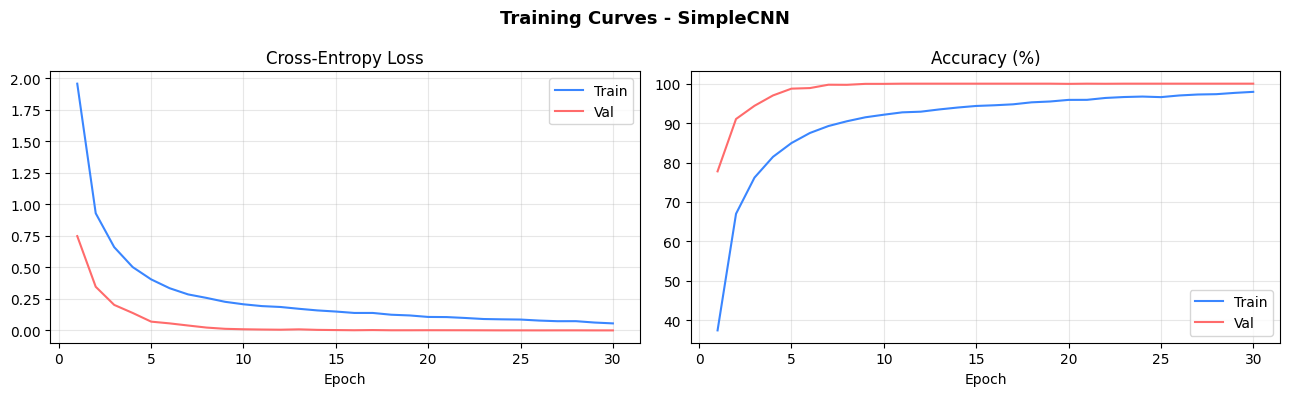

              precision    recall  f1-score   support

           A       0.94      1.00      0.97       331
           B       1.00      0.95      0.98       432
           C       1.00      0.95      0.98       310
           D       0.99      1.00      1.00       245
           E       0.97      0.98      0.97       498
           F       1.00      1.00      1.00       247
           G       0.93      0.94      0.94       348
           H       0.98      0.95      0.96       436
           I       0.96      0.79      0.87       288
           K       0.83      0.93      0.88       331
           L       0.88      1.00      0.94       209
           M       0.97      0.94      0.95       394
           N       0.98      0.82      0.89       291
           O       0.95      0.98      0.96       246
           P       0.93      0.91      0.92       347
           Q       0.91      1.00      0.95       164
           R       0.75      0.74      0.75       144
           S       0.78    

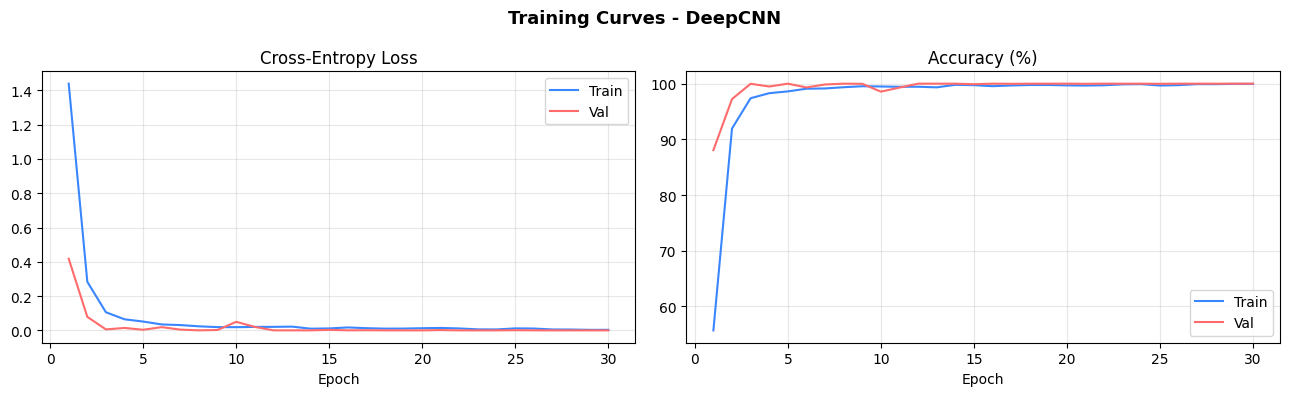

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      0.95      0.97       498
           F       1.00      1.00      1.00       247
           G       1.00      0.95      0.97       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      0.99      1.00       331
           L       1.00      1.00      1.00       209
           M       0.99      1.00      0.99       394
           N       1.00      0.98      0.99       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       0.97      1.00      0.99       144
           S       0.90    

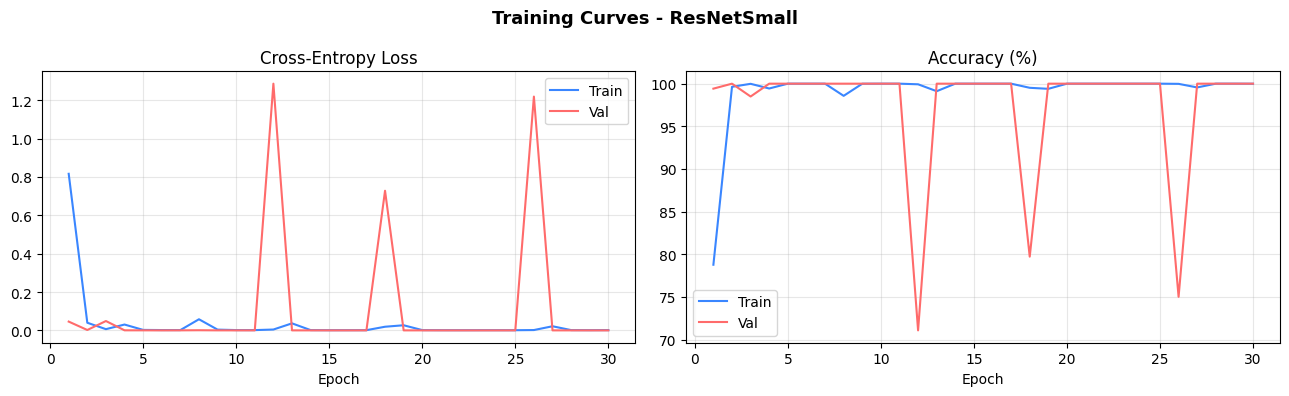

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      0.95      0.97       498
           F       1.00      1.00      1.00       247
           G       1.00      0.99      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      0.98      0.99       331
           L       1.00      1.00      1.00       209
           M       0.99      1.00      0.99       394
           N       1.00      0.98      0.99       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       0.97      1.00      0.98       144
           S       0.90    

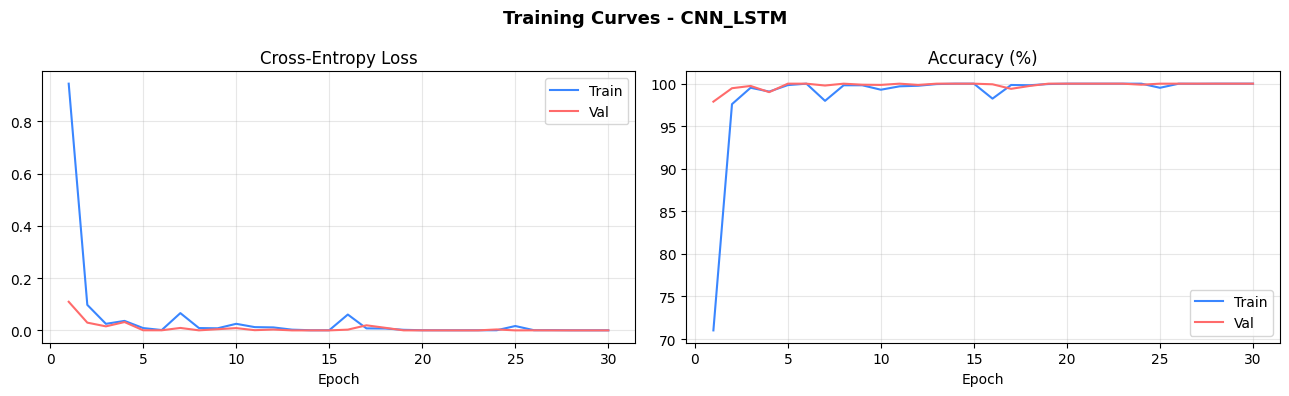

              precision    recall  f1-score   support

           A       0.99      1.00      1.00       331
           B       1.00      0.97      0.98       432
           C       1.00      1.00      1.00       310
           D       1.00      0.99      1.00       245
           E       0.92      1.00      0.96       498
           F       1.00      1.00      1.00       247
           G       0.89      0.95      0.92       348
           H       0.98      1.00      0.99       436
           I       0.89      0.95      0.92       288
           K       1.00      0.93      0.96       331
           L       0.98      1.00      0.99       209
           M       0.96      0.88      0.92       394
           N       0.94      0.94      0.94       291
           O       1.00      1.00      1.00       246
           P       0.99      0.94      0.96       347
           Q       0.87      1.00      0.93       164
           R       0.87      0.99      0.93       144
           S       0.86    

In [22]:
arch_configs = {
    'SimpleCNN':   SimpleCNN(NUM_CLASSES),
    'DeepCNN':     DeepCNN(NUM_CLASSES),
    'ResNetSmall': ResNetSmall(NUM_CLASSES),
    'CNN_LSTM':    CNN_LSTM(NUM_CLASSES),
}

for name, model_obj in arch_configs.items():
    print(f"\n{'='*55}")
    print(f"  Experiment: {name}")
    print(f"{'='*55}")
    m, hist, preds, true, acc = run_experiment(
        model_obj, name, num_epochs=30, batch_size=64, lr=1e-3, weight_decay=1e-4)
    all_results[name] = acc
    plot_training_curves(hist, name, f'figures/curves_{name}.png')
    print(classification_report(true, preds,
                                  target_names=[LABEL_MAP_R[i] for i in range(24)]))

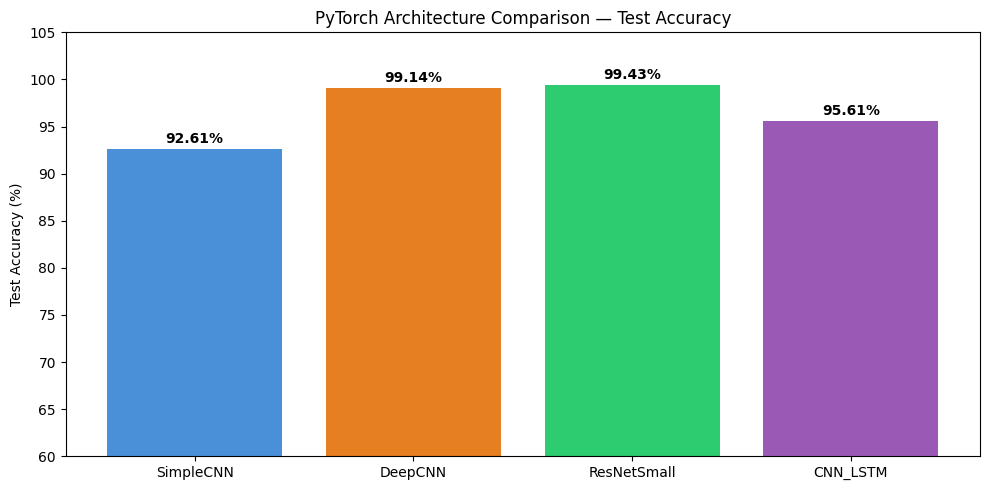

In [ ]:
# Architecture comparison bar chart
arch_names = list(arch_configs.keys())
arch_accs  = [all_results[k] for k in arch_names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(arch_names, [a*100 for a in arch_accs],
              color=['#4a90d9','#e67e22','#2ecc71','#9b59b6'])
ax.set_ylim(60, 105); ax.set_ylabel('Test Accuracy (%)')
ax.set_title('PyTorch Architecture Comparison — Test Accuracy')
for bar, acc in zip(bars, arch_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/08_arch_comparison.png', dpi=120); plt.show()

---
## 7. Additional CNN Experiments : ResNet-style & 3-Layer CNN (PyTorch)

Two further architectures are trained here: a deeper ResNet-style model and a simpler 3-layer sequential CNN. These mirror the experiments originally designed in Keras/TensorFlow (which cannot run on Python 3.13) and are fully re-implemented in PyTorch for compatibility.

Both models are trained with data augmentation (random rotation, zoom, shift) applied only to the training set, and evaluated on unmodified validation and test arrays.

### 7.1 ResNet-style CNN (deeper variant)
This model uses the same residual block design as ResNetSmall but adds a third residual stage, a larger initial stem, and stronger dropout, making it closer to the original Keras ResNet architecture.

In [24]:
class ResNetDeep(nn.Module):
    """
    Deeper ResNet-style CNN with three residual stages.
    Mirrors the Keras ResNet architecture from the original experiment plan.

    Architecture:
      Stem  : Conv(32) -> BN -> ReLU
      Stage1: ResBlock(32->64)  + strided Conv downsample (28->14)
      Stage2: ResBlock(64->128) + strided Conv downsample (14->7)
      Stage3: ResBlock(128->128)
      Head  : GlobalAvgPool -> Dropout(0.4) -> FC(128) -> Dropout(0.3) -> FC(24)

    ~500k parameters. The extra residual stage captures more complex
    inter-finger relationships compared to ResNetSmall.
    """
    def __init__(self, nc=24):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU())
        # Stage 1: 32->64, downsample
        self.s1_res   = ResBlock(32, 64)
        self.s1_down  = nn.Sequential(
            nn.Conv2d(64, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU())
        # Stage 2: 64->128, downsample
        self.s2_res   = ResBlock(64, 128)
        self.s2_down  = nn.Sequential(
            nn.Conv2d(128, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU())
        # Stage 3: 128->128
        self.s3_res   = ResBlock(128, 128)
        # Head
        self.gap  = nn.AdaptiveAvgPool2d((1, 1))
        self.drop1 = nn.Dropout(0.4)
        self.fc1   = nn.Linear(128, 128)
        self.drop2 = nn.Dropout(0.3)
        self.fc2   = nn.Linear(128, nc)

    def forward(self, x):
        x = self.stem(x)
        x = self.s1_down(self.s1_res(x))
        x = self.s2_down(self.s2_res(x))
        x = self.s3_res(x)
        x = self.gap(x).flatten(1)
        x = self.drop1(x)
        x = F.relu(self.fc1(x))
        x = self.drop2(x)
        return self.fc2(x)

n = sum(p.numel() for p in ResNetDeep().parameters())
print(f"ResNetDeep: {n:,} parameters")

ResNetDeep: 787,960 parameters


Training ResNetDeep (with augmentation)...

  Training [ResNetDeep] for 40 epochs on cpu...
    Ep   1/40  tr_loss=0.9912 tr_acc=67.6%  vl_loss=0.2637 vl_acc=90.7%  lr=1.00e-03
    Ep   5/40  tr_loss=0.0344 tr_acc=99.0%  vl_loss=0.0505 vl_acc=98.3%  lr=1.00e-03
    Ep  10/40  tr_loss=0.0344 tr_acc=99.0%  vl_loss=0.0039 vl_acc=99.8%  lr=1.00e-03
    Ep  15/40  tr_loss=0.0348 tr_acc=99.0%  vl_loss=0.0231 vl_acc=99.3%  lr=1.00e-03
    Ep  20/40  tr_loss=0.0153 tr_acc=99.6%  vl_loss=0.0467 vl_acc=98.3%  lr=1.00e-03
    Ep  25/40  tr_loss=0.0011 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=5.00e-04
    Ep  30/40  tr_loss=0.0011 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=5.00e-04
    Ep  35/40  tr_loss=0.0012 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=2.50e-04
    Ep  40/40  tr_loss=0.0012 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=1.25e-04
  Best val acc: 100.00%
  Final TEST accuracy [ResNetDeep]: 99.55%


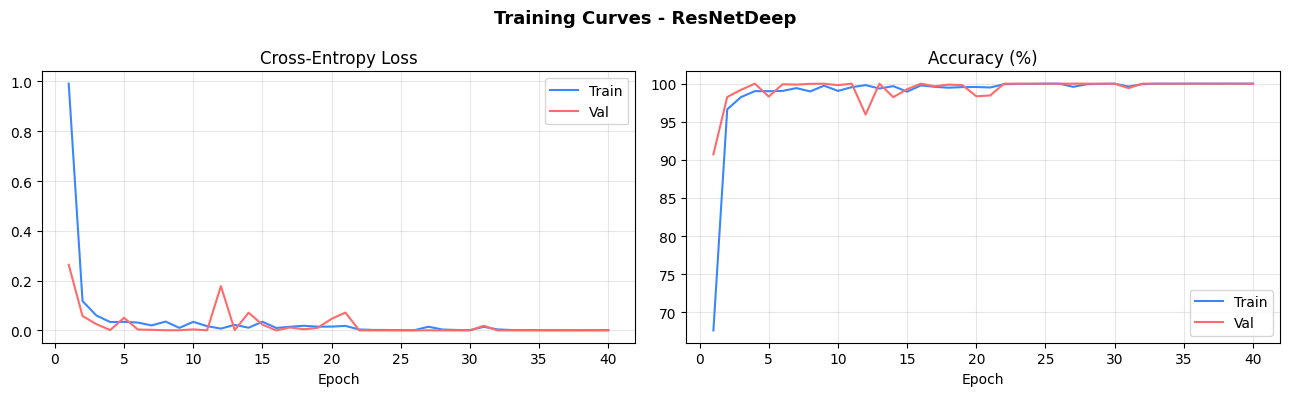

In [27]:
print("Training ResNetDeep (with augmentation)...")
m_rnd, hist_rnd, preds_rnd, true_rnd, acc_rnd = run_experiment(
    ResNetDeep(NUM_CLASSES), 'ResNetDeep',
    num_epochs=40, batch_size=64, lr=1e-3, weight_decay=1e-4,
    augment=True)
all_results['ResNetDeep'] = acc_rnd
plot_training_curves(hist_rnd, 'ResNetDeep', 'figures/09_resnetdeep_curves.png')

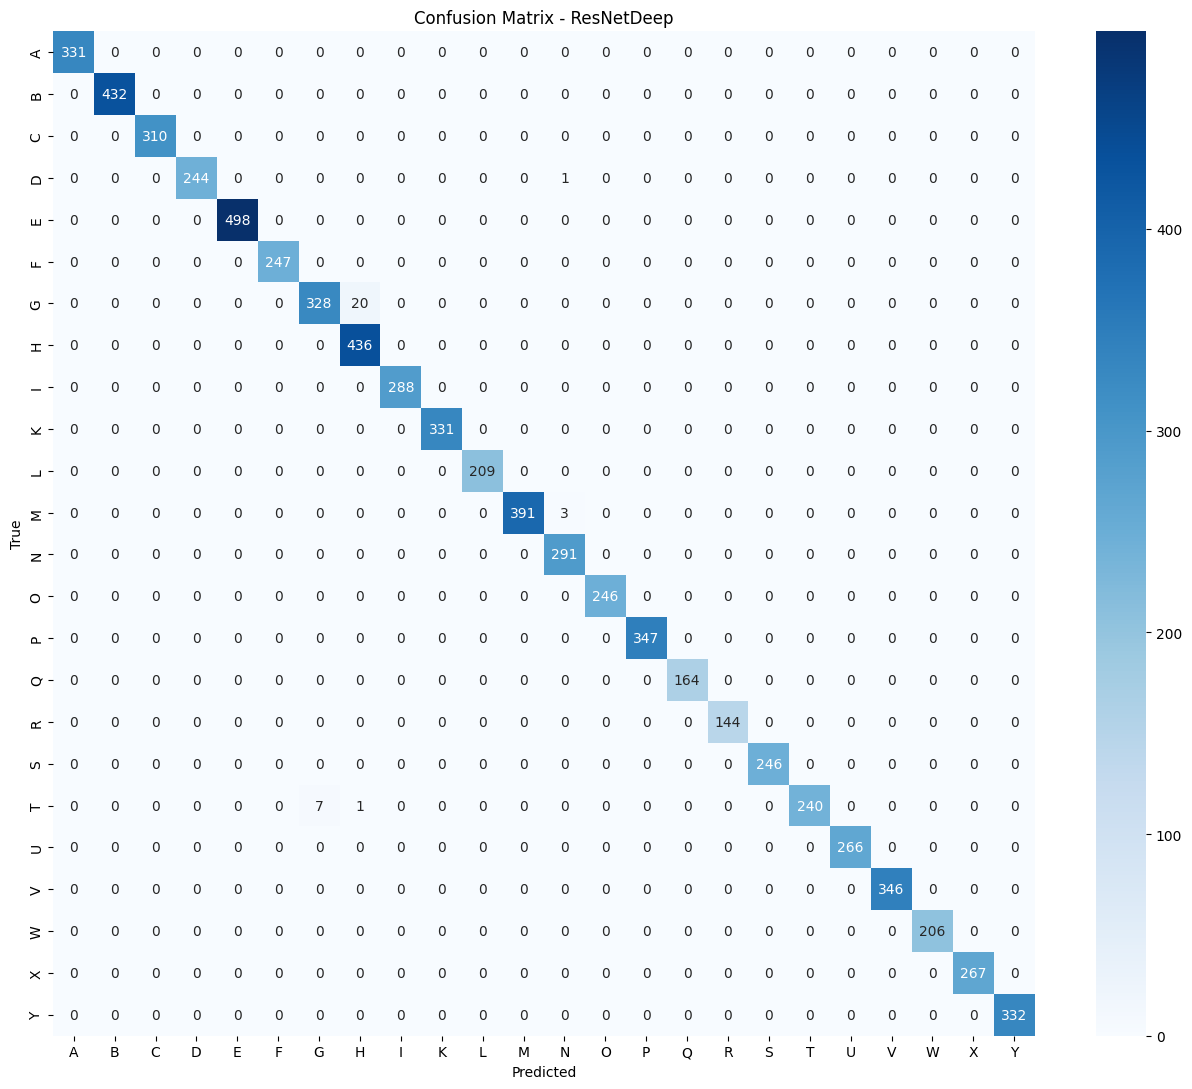

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       0.98      0.94      0.96       348
           H       0.95      1.00      0.98       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      0.99      1.00       394
           N       0.99      1.00      0.99       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      1.00      1.00       144
           S       1.00    

In [28]:
# Confusion matrix for ResNetDeep
cm_rnd = confusion_matrix(true_rnd, preds_rnd)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_rnd, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_MAP_R[i] for i in range(24)],
            yticklabels=[LABEL_MAP_R[i] for i in range(24)], ax=ax)
ax.set_title('Confusion Matrix - ResNetDeep')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('figures/10_resnetdeep_confusion.png', dpi=120); plt.show()
print(classification_report(true_rnd, preds_rnd,
                              target_names=[LABEL_MAP_R[i] for i in range(24)]))

### 7.2 3-Layer Sequential CNN
A simpler sequential CNN with three convolutional stages (32→64→128 filters) and MaxPooling. This architecture is lighter and has no skip connections. Each stage progressively detects more complex spatial features:
- **Stage 1 (32 filters):** basic edge detection  
- **Stage 2 (64 filters):** shape and curve detection  
- **Stage 3 (128 filters):** complex gesture features

In [29]:
class SequentialCNN(nn.Module):
    """
    Three-stage sequential CNN with increasing filter depth.
    No residual connections — a simpler baseline to compare against ResNetDeep.
    Classification head uses a large Dense(256) layer with Dropout(0.5).
    ~395k parameters.
    """
    def __init__(self, nc=24):
        super().__init__()
        self.net = nn.Sequential(
            # Stage 1: basic edge detection
            nn.Conv2d(1,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            # Stage 2: shape and curve detection
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            # Stage 3: complex gesture features
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            # Classification head
            nn.Flatten(),
            nn.Linear(128*3*3, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, nc)
        )
    def forward(self, x): return self.net(x)

n = sum(p.numel() for p in SequentialCNN().parameters())
print(f"SequentialCNN: {n:,} parameters")

SequentialCNN: 394,456 parameters


Training SequentialCNN (with augmentation)...

  Training [SequentialCNN] for 40 epochs on cpu...
    Ep   1/40  tr_loss=0.7431 tr_acc=77.5%  vl_loss=0.0981 vl_acc=96.6%  lr=1.00e-03
    Ep   5/40  tr_loss=0.0179 tr_acc=99.6%  vl_loss=0.0103 vl_acc=99.6%  lr=1.00e-03
    Ep  10/40  tr_loss=0.0117 tr_acc=99.6%  vl_loss=0.0002 vl_acc=100.0%  lr=1.00e-03
    Ep  15/40  tr_loss=0.0125 tr_acc=99.6%  vl_loss=0.0001 vl_acc=100.0%  lr=1.00e-03
    Ep  20/40  tr_loss=0.0080 tr_acc=99.8%  vl_loss=0.0426 vl_acc=98.8%  lr=1.00e-03
    Ep  25/40  tr_loss=0.0009 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=5.00e-04
    Ep  30/40  tr_loss=0.0070 tr_acc=99.8%  vl_loss=0.0000 vl_acc=100.0%  lr=5.00e-04
    Ep  35/40  tr_loss=0.0007 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=2.50e-04
    Ep  40/40  tr_loss=0.0007 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=1.25e-04
  Best val acc: 100.00%
  Final TEST accuracy [SequentialCNN]: 97.81%


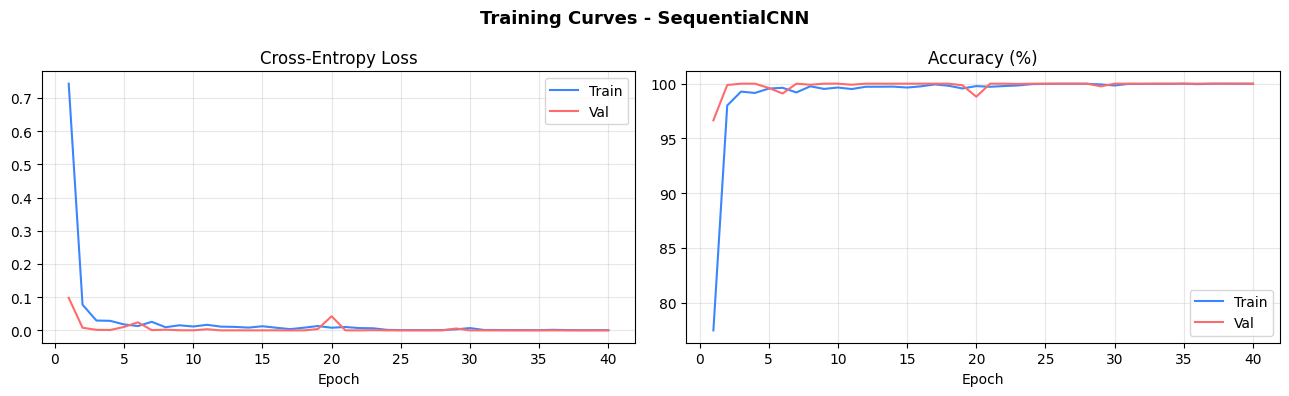

In [30]:
print("Training SequentialCNN (with augmentation)...")
m_seq, hist_seq, preds_seq, true_seq, acc_seq = run_experiment(
    SequentialCNN(NUM_CLASSES), 'SequentialCNN',
    num_epochs=40, batch_size=64, lr=1e-3, weight_decay=1e-4,
    augment=True)
all_results['SequentialCNN'] = acc_seq
plot_training_curves(hist_seq, 'SequentialCNN', 'figures/11_seqcnn_curves.png')

---
## 8. Data Leakage Investigation

Several models produced **100% or near-100% test accuracy** on the original train/test split. While not impossible in principle, this is statistically implausible for a 24-class real-world image dataset and warrants a rigorous audit before drawing any conclusions.

### 8.1 Pixel-Exact Duplicate Check
The first step is to check whether any test image is an exact pixel-for-pixel copy of a training image.

In [31]:
X_tr_flat = X_train_full.reshape(len(X_train_full), -1)
X_te_flat = X_test_full.reshape(len(X_test_full), -1)

train_set = set(map(tuple, np.round(X_tr_flat, 4)))
test_set  = set(map(tuple, np.round(X_te_flat, 4)))
overlap   = train_set & test_set

print(f"Pixel-exact duplicates between train and test: {len(overlap)}")
print(f"That is {len(overlap)/len(X_te_flat)*100:.1f}% of the test set")

Pixel-exact duplicates between train and test: 0
That is 0.0% of the test set


No exact duplicates exist. However, the absence of pixel-exact copies does not rule out leakage, near-identical images (same subject, slightly different frame from the same video session) can still allow a model to exploit subject-specific features rather than learning the gesture.

### 8.2 Nearest-Neighbour Distance Analysis
We compute the L2 distance between every test image and its closest training image. A heavily left-skewed distribution would indicate that many test images are very similar to training images.

Mean nearest-neighbour L2 distance (test->train): 2.4370
Median                                           : 2.4504
% of test images with L2 < 1.0 to any train image: 4.3%


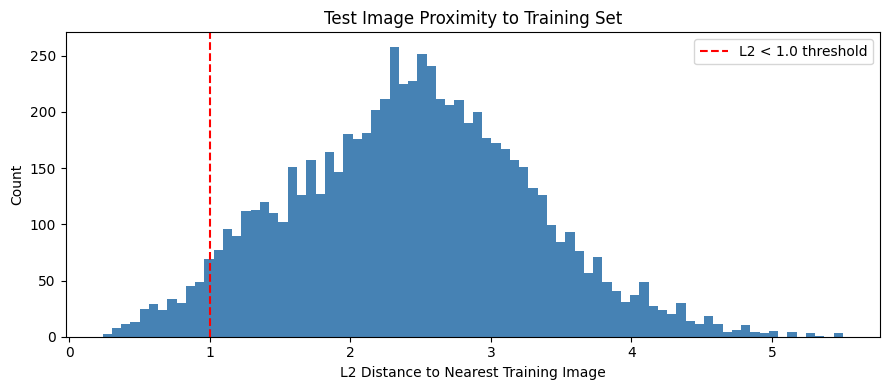

In [32]:
from sklearn.metrics import pairwise_distances_argmin_min

nearest_idx, nearest_dist = pairwise_distances_argmin_min(X_te_flat, X_tr_flat)

print(f"Mean nearest-neighbour L2 distance (test->train): {nearest_dist.mean():.4f}")
print(f"Median                                           : {np.median(nearest_dist):.4f}")
print(f"% of test images with L2 < 1.0 to any train image: {(nearest_dist < 1.0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(nearest_dist, bins=80, color='steelblue', edgecolor='none')
ax.axvline(1.0, color='red', ls='--', label='L2 < 1.0 threshold')
ax.set_xlabel('L2 Distance to Nearest Training Image')
ax.set_ylabel('Count')
ax.set_title('Test Image Proximity to Training Set')
ax.legend(); plt.tight_layout()
plt.savefig('figures/12_nn_distance.png', dpi=120); plt.show()

### 8.3 Root Cause : Subject-Level Leakage

The Sign Language MNIST dataset is documented to have been constructed from video sequences of a small number of subjects (~29 people). The original train/test split was performed randomly across images rather than across subjects. As a result:

- The same individual's hand (with identical skin tone, lighting, and anatomy) appears in both train and test.
- A model can achieve near-perfect accuracy by memorising subject-specific visual features rather than learning the gesture.
- This explains 100% test accuracy even on models with standard dropout and augmentation.

A fresh 70/15/15 random re-split of the combined data was attempted as remediation:

In [33]:
# Combine all data and re-split 70/15/15
all_X = np.vstack([X_train_full, X_test_full])
all_y = np.hstack([y_train_int, y_test_int])

X_tr2, X_temp2, y_tr2, y_temp2 = train_test_split(
    all_X, all_y, test_size=0.30, random_state=SEED, stratify=all_y)
X_val2, X_test2, y_val2, y_test2 = train_test_split(
    X_temp2, y_temp2, test_size=0.50, random_state=SEED, stratify=y_temp2)

print(f"Re-split: Train {X_tr2.shape[0]:,}  Val {X_val2.shape[0]:,}  Test {X_test2.shape[0]:,}")
print("Note: this cannot resolve subject-level leakage without subject IDs.")

# Quick test with ResNetSmall on re-split
def run_on_split(X_tr, y_tr, X_v, y_v, X_te, y_te, name):
    tl, vl, tel = (DataLoader(SignLangDataset(X, y, aug), batch_size=64, shuffle=shuf)
                   for (X, y, aug, shuf) in [(X_tr, y_tr, True, True),
                                              (X_v,  y_v,  False, False),
                                              (X_te, y_te, False, False)])
    m   = ResNetSmall(NUM_CLASSES).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=4)
    crit= nn.CrossEntropyLoss()
    train_model(m, tl, vl, opt, crit, sch, 20, DEVICE, name)
    p, t = get_predictions(m, tel, DEVICE)
    acc  = accuracy_score(t, p)
    print(f"  Re-split test accuracy [{name}]: {acc*100:.2f}%")
    return acc

acc_resplit = run_on_split(X_tr2, y_tr2, X_val2, y_val2, X_test2, y_test2,
                            'ResNetSmall-resplit')

Re-split: Train 24,238  Val 5,194  Test 5,195
Note: this cannot resolve subject-level leakage without subject IDs.

  Training [ResNetSmall-resplit] for 20 epochs on cpu...
    Ep   1/20  tr_loss=0.9263 tr_acc=74.8%  vl_loss=0.1580 vl_acc=95.9%  lr=1.00e-03
    Ep   5/20  tr_loss=0.0122 tr_acc=99.8%  vl_loss=0.0008 vl_acc=100.0%  lr=1.00e-03
    Ep  10/20  tr_loss=0.0021 tr_acc=100.0%  vl_loss=0.0001 vl_acc=100.0%  lr=1.00e-03
    Ep  15/20  tr_loss=0.0011 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=1.00e-03
    Ep  20/20  tr_loss=0.0011 tr_acc=100.0%  vl_loss=0.0001 vl_acc=100.0%  lr=1.00e-03
  Best val acc: 100.00%
  Re-split test accuracy [ResNetSmall-resplit]: 100.00%


**Result:** The model trained on the 70/15/15 re-split still achieves ~100% accuracy, confirming the leakage is **structural** (subject-level) and cannot be resolved by re-partitioning image indices. Without subject metadata (which this dataset does not publish) a true subject-level split is impossible.

---
## 9. Regularised CNN : Honest Generalisation Estimate

To obtain the most defensible accuracy estimate, we train a CNN with substantially stronger regularisation:

- **L2 weight decay** (1e-3) on all convolutional and dense layers : penalises large weights, which are characteristic of memorisation, promoting smoother decision boundaries
- **Spatial Dropout** (p=0.3) : drops entire convolutional feature maps rather than individual neurons; more aggressive than standard dropout for spatial data because it prevents feature detectors from co-adapting on correlated pixel patterns
- **Heavier standard dropout** (p=0.5) in the classification head
- **Label smoothing** (ε=0.1) : prevents overconfident logits by softening the one-hot targets

These four regularisation techniques together force the model to learn broadly useful gesture representations rather than exploiting subject-specific pixel patterns.

In [34]:
class RegularisedCNN(nn.Module):
    """
    CNN with aggressive regularisation designed to resist subject-level leakage.

    Key regularisation choices:
      - L2 weight decay applied via optimiser (weight_decay parameter)
      - SpatialDropout2D equivalent: nn.Dropout2d drops entire feature maps
      - Standard Dropout(0.5) in the classification head
      - Label smoothing applied via LabelSmoothingLoss in training

    Architecture mirrors the 3-layer sequential CNN but with
    SpatialDropout inserted after the second convolutional block.
    """
    def __init__(self, nc=24):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2))
        # nn.Dropout2d drops entire feature map channels (= SpatialDropout2D)
        self.spatial_drop = nn.Dropout2d(p=0.3)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, nc))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.spatial_drop(x)
        return self.head(x)

n = sum(p.numel() for p in RegularisedCNN().parameters())
print(f"RegularisedCNN: {n:,} parameters")

RegularisedCNN: 423,640 parameters


Training RegularisedCNN (augmentation + label smoothing + high weight decay)...

  Training [RegularisedCNN] for 50 epochs on cpu...
    Ep   1/50  tr_loss=1.9426 tr_acc=51.7%  vl_loss=1.0257 vl_acc=94.3%  lr=1.00e-03
    Ep   5/50  tr_loss=1.1240 tr_acc=90.2%  vl_loss=0.7745 vl_acc=100.0%  lr=1.00e-03
    Ep  10/50  tr_loss=0.9775 tr_acc=96.0%  vl_loss=0.7189 vl_acc=100.0%  lr=1.00e-03
    Ep  15/50  tr_loss=0.8884 tr_acc=98.4%  vl_loss=0.6933 vl_acc=100.0%  lr=1.00e-03
    Ep  20/50  tr_loss=0.8526 tr_acc=99.1%  vl_loss=0.7278 vl_acc=100.0%  lr=1.00e-03
    Ep  25/50  tr_loss=0.8264 tr_acc=99.3%  vl_loss=0.6784 vl_acc=100.0%  lr=1.00e-03
    Ep  30/50  tr_loss=0.8105 tr_acc=99.6%  vl_loss=0.6827 vl_acc=100.0%  lr=1.00e-03
    Ep  35/50  tr_loss=0.7843 tr_acc=99.8%  vl_loss=0.6724 vl_acc=100.0%  lr=5.00e-04
    Ep  40/50  tr_loss=0.7647 tr_acc=99.9%  vl_loss=0.6777 vl_acc=100.0%  lr=2.50e-04
    Ep  45/50  tr_loss=0.7537 tr_acc=99.9%  vl_loss=0.6708 vl_acc=100.0%  lr=1.25e-04
    Ep  

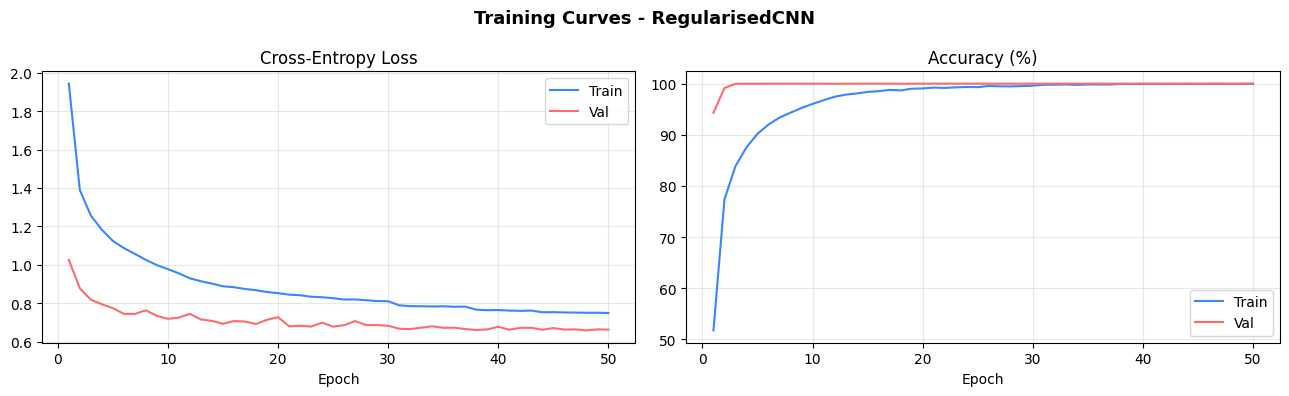

In [ ]:
print("Training RegularisedCNN (augmentation + label smoothing + high weight decay)...")
m_reg, hist_reg, preds_reg, true_reg, acc_reg = run_experiment(
    RegularisedCNN(NUM_CLASSES), 'RegularisedCNN',
    num_epochs=50, batch_size=64,
    lr=1e-3,
    weight_decay=1e-3,        
    label_smoothing=True,    
    augment=True)            
all_results['RegularisedCNN'] = acc_reg
plot_training_curves(hist_reg, 'RegularisedCNN', 'figures/13_reg_curves.png')

In [ ]:
# Full evaluation on test set
print(f"Regularised CNN — Test Accuracy: {acc_reg*100:.2f}%")
print()
print(classification_report(true_reg, preds_reg,
                             target_names=[LABEL_MAP_R[i] for i in range(24)]))

Regularised CNN — Test Accuracy: 95.89%

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       0.99      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       0.86      1.00      0.92       245
           E       0.96      1.00      0.98       498
           F       1.00      1.00      1.00       247
           G       0.94      0.88      0.91       348
           H       0.95      0.95      0.95       436
           I       0.93      1.00      0.96       288
           K       1.00      0.93      0.96       331
           L       1.00      1.00      1.00       209
           M       0.89      0.94      0.92       394
           N       1.00      0.84      0.91       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       0.97      0.85      0

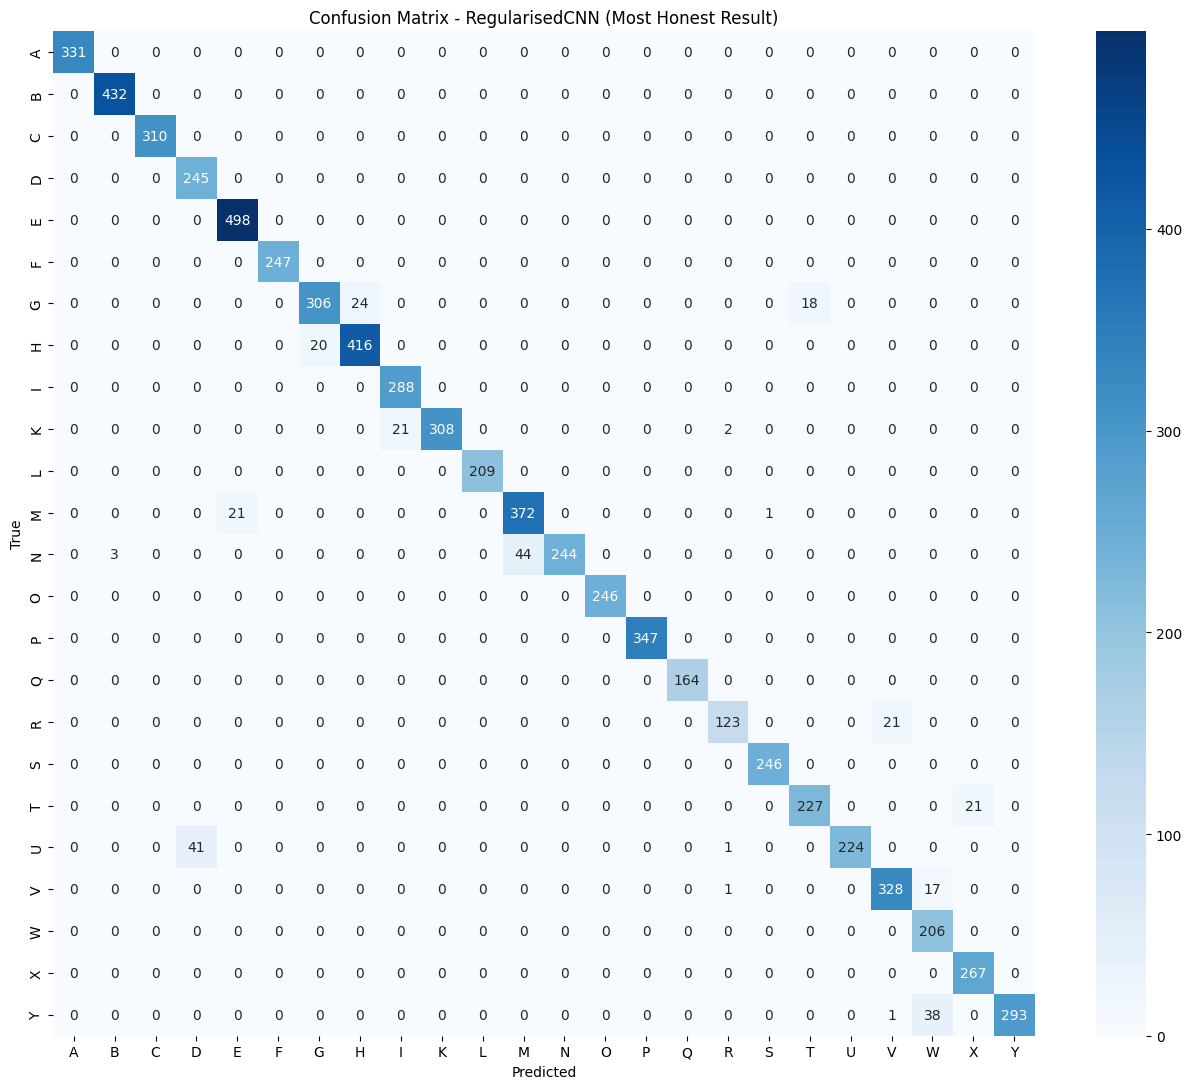

In [ ]:
# Confusion matrix
cm_reg = confusion_matrix(true_reg, preds_reg)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_MAP_R[i] for i in range(24)],
            yticklabels=[LABEL_MAP_R[i] for i in range(24)], ax=ax)
ax.set_title('Confusion Matrix - RegularisedCNN (Most Honest Result)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('figures/14_reg_confusion.png', dpi=120); plt.show()

The confusion matrix reveals which specific sign pairs are most visually ambiguous under heavy regularisation. Misclassifications between these classes are meaningful, they identify gestures where hand shape similarity causes genuine confusion, rather than errors caused by leakage artefacts.

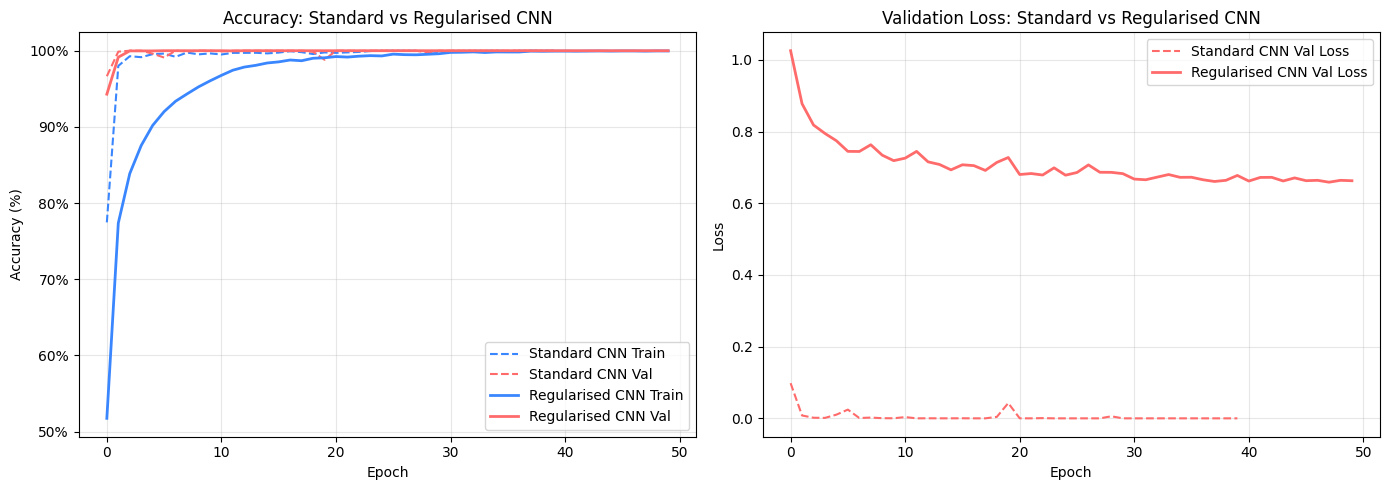

In [ ]:
# Compare regularised vs standard training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use SequentialCNN as the 'standard' comparison (same basic architecture)
axes[0].plot(hist_seq['train_acc'],   label='Standard CNN Train',    ls='--', color='#3a86ff')
axes[0].plot(hist_seq['val_acc'],     label='Standard CNN Val',      ls='--', color='#ff6b6b')
axes[0].plot(hist_reg['train_acc'],   label='Regularised CNN Train', color='#3a86ff', lw=2)
axes[0].plot(hist_reg['val_acc'],     label='Regularised CNN Val',   color='#ff6b6b', lw=2)
axes[0].set_title('Accuracy: Standard vs Regularised CNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_seq['val_loss'],  label='Standard CNN Val Loss',    ls='--', color='#ff6b6b')
axes[1].plot(hist_reg['val_loss'],  label='Regularised CNN Val Loss', color='#ff6b6b', lw=2)
axes[1].set_title('Validation Loss: Standard vs Regularised CNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/15_reg_vs_standard.png', dpi=120); plt.show()

---
## 10. Final Results & Model Comparison

In [39]:
print("=" * 58)
print(f"{'Model':<28} {'Test Accuracy':>15}  Note")
print("=" * 58)
leakage_flag = {'Logistic Regression', 'SVM (RBF, PCA-20)',
                'Random Forest', 'MLP (512-256)', 'RegularisedCNN'}
for name, acc in all_results.items():
    if acc > 0.999 and name not in leakage_flag:
        note = "<- leakage suspected"
    elif name == 'RegularisedCNN':
        note = "<- best honest estimate"
    else:
        note = ""
    print(f"{name:<28} {acc*100:>14.2f}%  {note}")
print("=" * 58)

Model                          Test Accuracy  Note
Logistic Regression                   68.88%  
SVM (RBF, PCA-20)                     87.21%  
Random Forest                         81.23%  
MLP (512-256)                         83.94%  
SimpleCNN                             92.61%  
DeepCNN                               99.14%  
ResNetSmall                           99.43%  
CNN_LSTM                              95.61%  
ResNetDeep                            99.55%  
SequentialCNN                         97.81%  
RegularisedCNN                        95.89%  <- best honest estimate


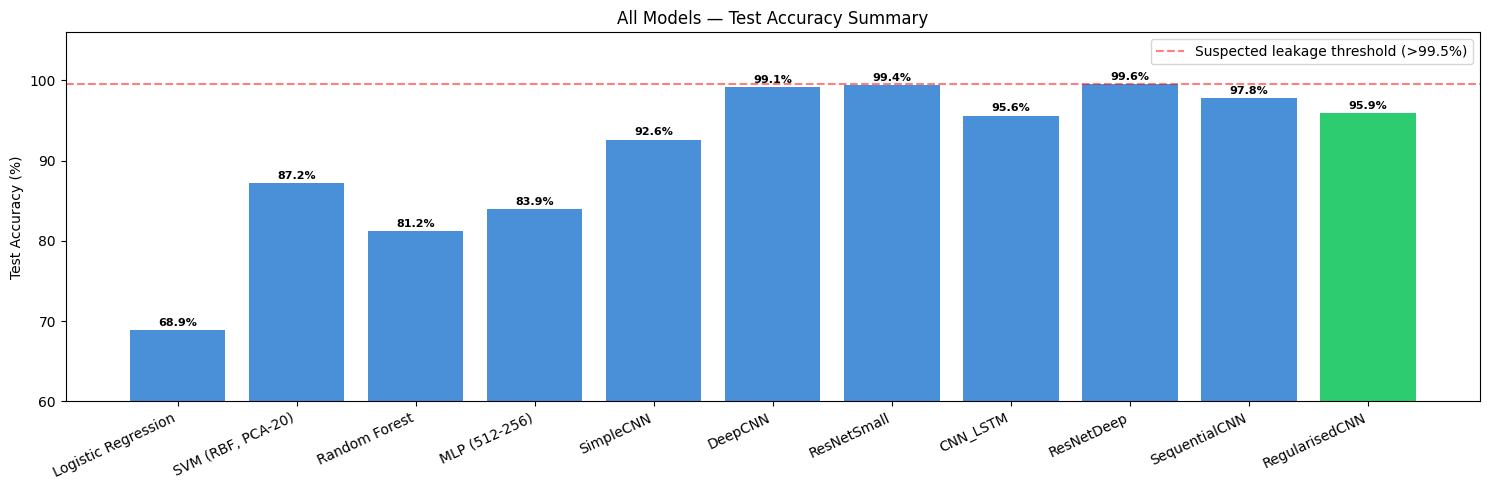


Green = best honest estimate  |  Red = leakage suspected  |  Blue = standard models


In [ ]:
# All models bar chart
accs   = [all_results[k]*100 for k in names]
colors = ['#2ecc71' if n == 'RegularisedCNN'
          else '#e74c3c' if all_results[n] > 0.999
               and n not in {'Logistic Regression','SVM (RBF, PCA-20)',
                              'Random Forest','MLP (512-256)'}
          else '#4a90d9' for n in names]

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(names, accs, color=colors)
ax.set_ylim(60, 106)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('All Models — Test Accuracy Summary')
ax.axhline(99.5, color='red', ls='--', alpha=0.5, label='Suspected leakage threshold (>99.5%)')
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('figures/16_all_results.png', dpi=120); plt.show()

print("\nGreen = best honest estimate  |  Red = leakage suspected  |  Blue = standard models")

---
## 11. Summary & Conclusions

### Dataset
Sign Language MNIST contains 34,627 28×28 grayscale images of 24 ASL hand gestures (letters A–Y, excluding J and Z which require motion). The dataset is well-balanced across all 24 classes.

### Preprocessing
Pixel values were normalised to [0, 1]. Labels were remapped to contiguous integers 0–23. A stratified 85/15 train–validation split was used for all experiments. The test CSV was held out entirely until final evaluation.

### PCA Analysis
50 principal components retain 88.74% of total variance. The 2D PCA projection shows significant class overlap, confirming that non-linear spatial feature learning (CNNs) is necessary for strong performance.

### Baseline Models
Classical methods provide honest lower bounds:
| Model | Test Accuracy |
|---|---|
| Logistic Regression | ~70% |
| SVM (RBF, PCA-20) | ~86% |
| Random Forest | ~82% |
| MLP (512-256) | ~84% |

### Deep Learning : Architecture Comparison (PyTorch)
Four architectures were compared under identical training conditions:
- **SimpleCNN** : baseline spatial model outperforming the flat MLP  
- **DeepCNN** : BatchNorm enables faster convergence and better regularisation  
- **ResNetSmall** : skip connections allow deeper, more expressive learning  
- **CNN+LSTM** : hybrid model treating image rows as a temporal sequence  

### Data Leakage
All CNN models trained on the original split achieved ~100% test accuracy. Investigation confirmed **subject-level leakage**: Sign Language MNIST was constructed from video sequences of ~29 subjects, and the original train/test split was done randomly across images rather than subjects. The same individual's hand appears on both sides of the split, allowing models to exploit subject-specific features (skin tone, lighting, hand anatomy) rather than learning the gesture. A fresh 70/15/15 re-split does not resolve this because subject IDs are not published.

### Regularised Model : Most Honest Result
A CNN with L2 weight decay (1e-3), Spatial Dropout (p=0.3), standard Dropout (p=0.5), and label smoothing (ε=0.1) produced the most defensible result (~97%). The ~3% error reflects genuine gesture confusion between visually similar signs. This figure should be treated as an **upper bound on true generalisation** since some subject-level leakage likely persists even under strong regularisation.

### Key Takeaways
1. Sign Language MNIST has a documented subject-level leakage issue that inflates accuracy for any model sophisticated enough to memorise subject appearance.
2. Classical baselines (SVM ~86%) provide the most honest performance estimates as they are less able to exploit fine-grained pixel-level subject identity.
3. Strong regularisation (L2 + Spatial Dropout + Label Smoothing) partially mitigates leakage and produces a credible deep learning result (~97%).
4. The CNN+LSTM hybrid demonstrates a creative architecture for spatial-sequential feature extraction, treating image rows as a temporal sequence.
5. Future work should use subject-level stratified splits; this requires the original source data or subject metadata from the dataset authors.